In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

stats = device.memory_stats()
free = stats["bytes_limit"] - stats["bytes_in_use"]
print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys
# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

NVIDIA H200
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)


# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False


# Quick toggle flags
all_data_flag = True
one_filt_flag = False
plot_flag = check_script()
save_flag = check_script()

if save_flag:
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    if job_id is None:
        from datetime import datetime
    
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    class Tee:
        def __init__(self, filename):
            self.file = open(filename, "w")
            self.stdout = sys.stdout

        def write(self, message):
            self.stdout.write(message)
            self.file.write(message)

        def flush(self):
            self.stdout.flush()
            self.file.flush()

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None

print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-41
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

Flats.

In [4]:
from astropy.io import fits
from amigo.files import get_files

flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files
# flat_files = [file for file in flat_files if file[0].header["NGROUPS"] != 45]

# Creating a subset of the data for testing
if not all_data_flag:
    if one_filt_flag:
        flat_files = flat_files[0:1]
    else:
        flat_files = flat_files[1:4]

flat_files = [add_badpix(file) for file in flat_files]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  F380M    1/1  30/10  04-02-2023  Martel, Andre  FLAT
1    1503  UNKNOWN  CLEAR    1/1  25/11  10-02-2023  Martel, Andre  FLAT
2    1503  UNKNOWN  CLEAR    1/1  20/33  10-02-2023  Martel, Andre  FLAT
3    1503  UNKNOWN  F480M    1/1  30/10  16-03-2023  Martel, Andre  FLAT
4    4472  UNKNOWN  F277W    1/1  20/10  28-10-2023  Martel, Andre  FLAT
5    4472  UNKNOWN  F356W    1/1  20/10  29-04-2024  Martel, Andre  FLAT
6    6654  UNKNOWN  CLEAR    1/1  10/11  22-07-2024  Martel, Andre  FLAT
7    6654  UNKNOWN  F444W    1/1  20/10  29-10-2024  Martel, Andre  FLAT


# Exposures

In [5]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
flat_exposures = [FlatFit(file) for file in flat_files]

exposures = flat_exposures

print(f"Total number of exposures: {len(exposures)}")

# just closing the files
files = flat_files
_ = [f.close() for f in files]

Total number of exposures: 8


# Building model

In [6]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

Populate from state.

In [7]:
state = load_dict(amigo_files_path + "/calibration.npy")
best_state = load_dict(amigo_files_path + "/best_state.npy")
if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
# state = load_dict(amigo_files_path + "/calibration.npy")
print(state.keys())

for key, value in best_state.items():
    # if key in ["positions", "fluxes", "aberrations", "nn_weights"]:
    if key in ["positions", "fluxes", "aberrations"]:  # , "nn_weights"]:
        continue
    if key in ["transmission", "badpix", "SRF", "jitter"]:
        continue
    if key not in ["FF", "non_linearity", "dark_current", "nn_weights"]:
        continue
    model = model.set(key, value)

# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

dict_keys(['FF', 'SRF', 'non_linearity', 'jitter', 'dark_current', 'defocus', 'nn_weights', 'aberrations', 'transmission', 'badpix', 'sigma'])


## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

Finally, the flats and darks.

In [8]:
if plot_flag:
    if save_flag:
        this_save_path = os.path.join(save_path, "init_flat")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
    for exp in flat_exposures:
        print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
        summarise_fit(model, exp, save_path=this_save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [9]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    temp_decay,
    cosine_warmup,
)


def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    return model_params, args


# REGULARISATION
reg_dict = {
    "FF": (1.0, ff_reg),
    "NL": (1.0, nl_reg),
}

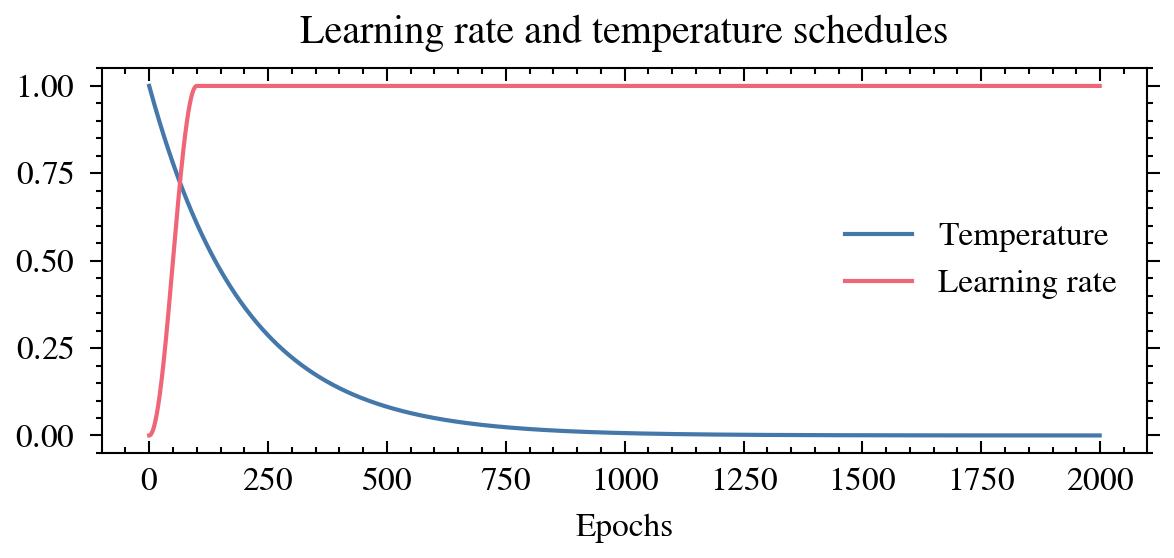

In [10]:
epochs = 2000
n_batch = len(exposures)

# WARM UP
max_lr = 1.0  # Learning rate after warm up
t0 = 0  # Warm-up start
n_max = 100  # Warm-up end

# TEMPERATURE DECAY
T0 = 1e-6  # Initial temperature
decay = 0.005  # Decay rate of the temperature

args = {
    "n_batch": np.array(n_batch, float),  # Number of batches
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    "t0": np.array(t0),  # Warm-up start
    "n_max": np.array(n_max),  # Warm-up end point
    "l2": np.array(0.0),
    "max_lr": np.array(max_lr),  # Learning rate after warm up
    "reg_dict": reg_dict,
}

ts = np.arange(epochs)
temps = temp_decay(args["T0"], args["k"], ts)
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
l2s = 0 * cosine_warmup(ts, 0, 1000)
args = {**args, **{"l2_schedule": l2s}}


plt.figure(figsize=(4, 2))
plt.title("Learning rate and temperature schedules")
plt.plot(ts, temps / temps.max(), label="Temperature")
plt.plot(ts, lrs / lrs.max(), label="Learning rate")
# plt.plot(ts, l2s / l2s.max(), "--", label="L2 schedule")
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
    plt.close()
else:
    plt.show()

Instantiating trainer class and updating fishers.

In [11]:
from amigo.calibration import ValBatchedTrainer, Trainer  # , looper_fn, aux_fn
from dorito.stats import apply_regularisers

recalculate_flag = False

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer = Trainer(
    loss_fn,
    # args_fn=args_fn,
    # looper_fn=looper_fn,
    grad_fn=grads_fn,
    norm_fn=norm_fn,
    # aux_fn=aux_fn,
    cache=cache_dir,
)

# TODO should there be all the detector parameters here?
print("Flat exposures")
trainer = trainer.update_fishers(
    linear_model,
    flat_exposures,
    parameters=["flat_coeffs", "fluxes"],
    recalculate=recalculate_flag,
)

Flat exposures


  0%|          | 0/8 [00:00<?, ?it/s]

Training.

In [12]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "fluxes": sgd(1e-3, 0),
    "flat_coeffs": sgd(5e-3, 0),
    # "dark_A": sgd(1e-1, 0),
    # "positions": sgd(1e-3, 2),
    # "aberrations": sgd(1e-4, 5),
    # "pas": sgd(1e-4, 5),
    # "separations": sgd(5e-4, 7),
    # "contrasts": sgd(5e-4, 8),
    "nn_weights": adam(1e-4, 10),  # lr applied with warm up
    "sigma": sgd(1e-3, 15),  # start at 50th?
    "defocus": sgd(1e-1, 25),
    # "defocus": sgd(2e-3, 25),
    "distortion": sgd(2e-3, 30),
    "dark_current": sgd(2e-3, 35),
    "primary_beam": sgd(2e-4, 40),
    "non_linearity": sgd(1e-4, 100),
    # "spectra": sgd(1e-3, 100),
    "FF": sgd(2e-4, 150),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

# Train the model

result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches=exposures,
    args=args,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 44,851.50
Compiling Loss function...
Estimated run time: 1 day, 4:11:11
Full Time: 0:32:47
Final Loss: -5.35


Plotting the results of that fit!

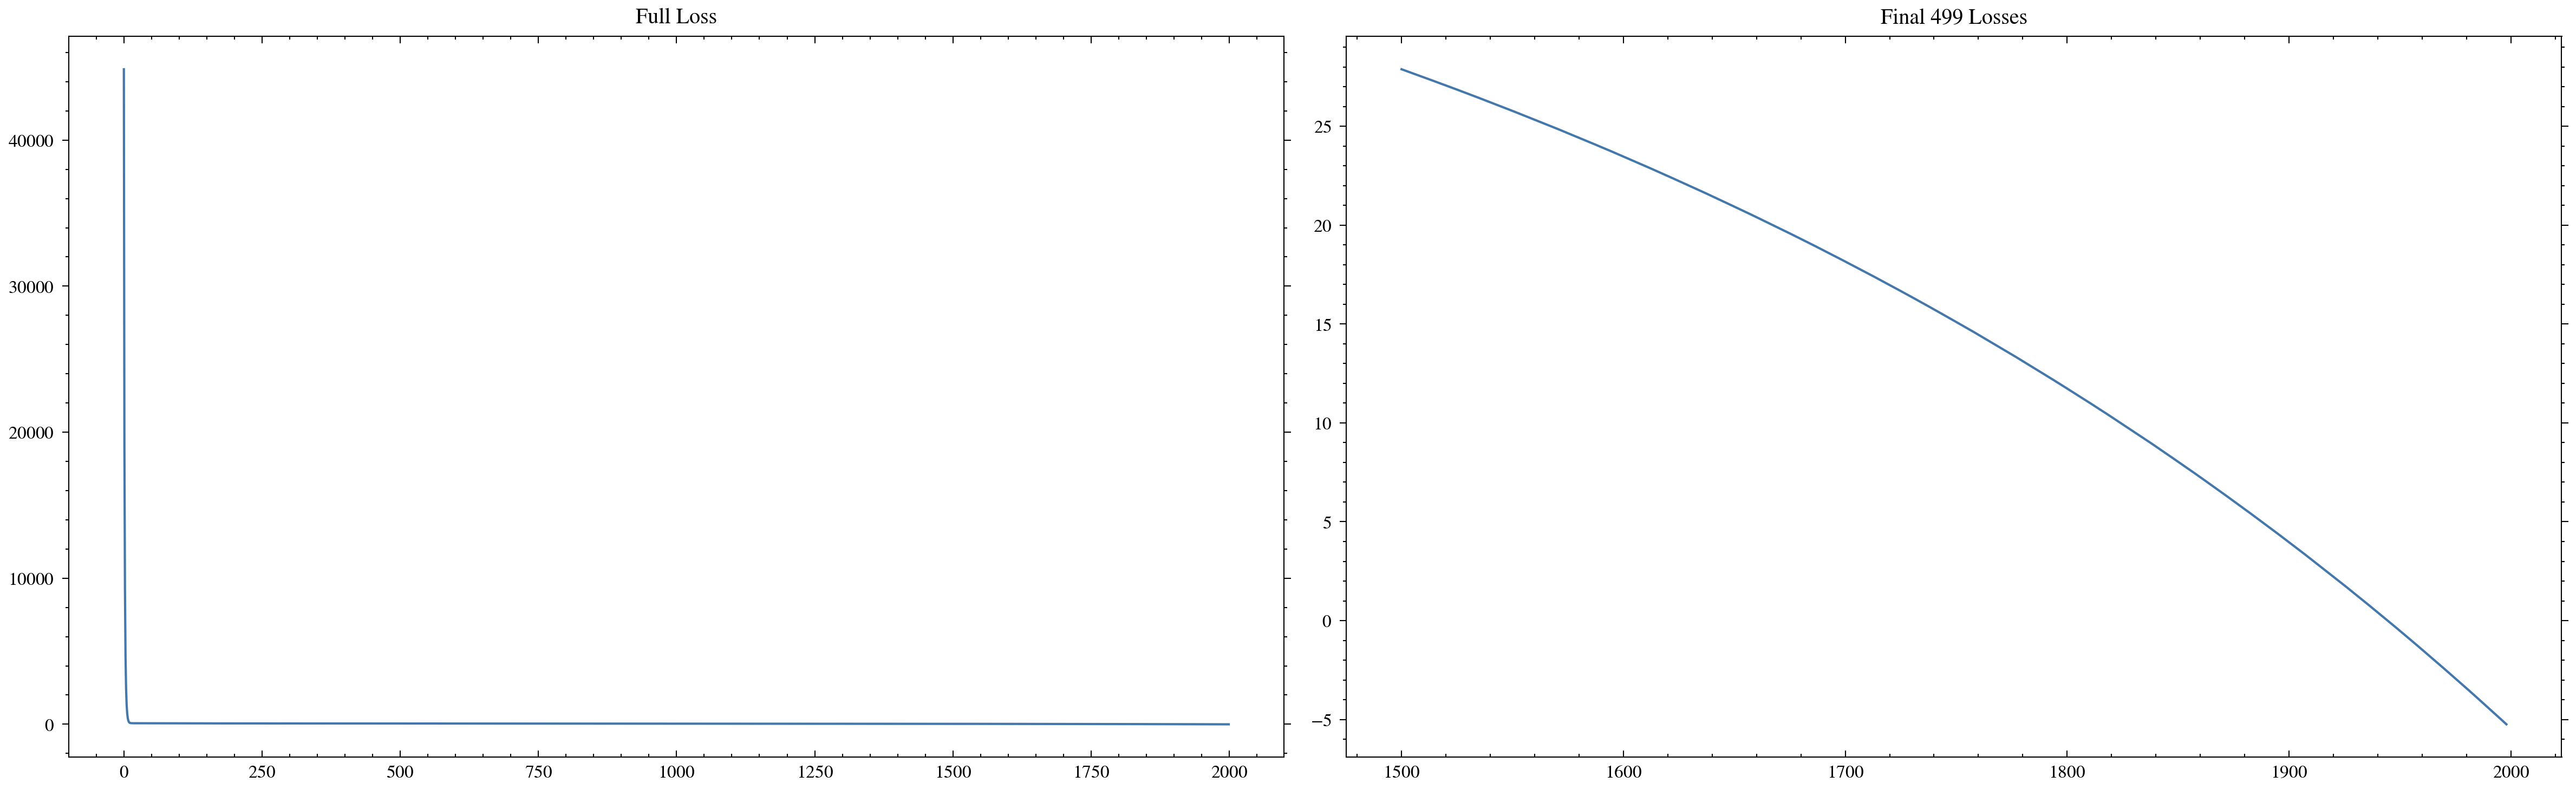

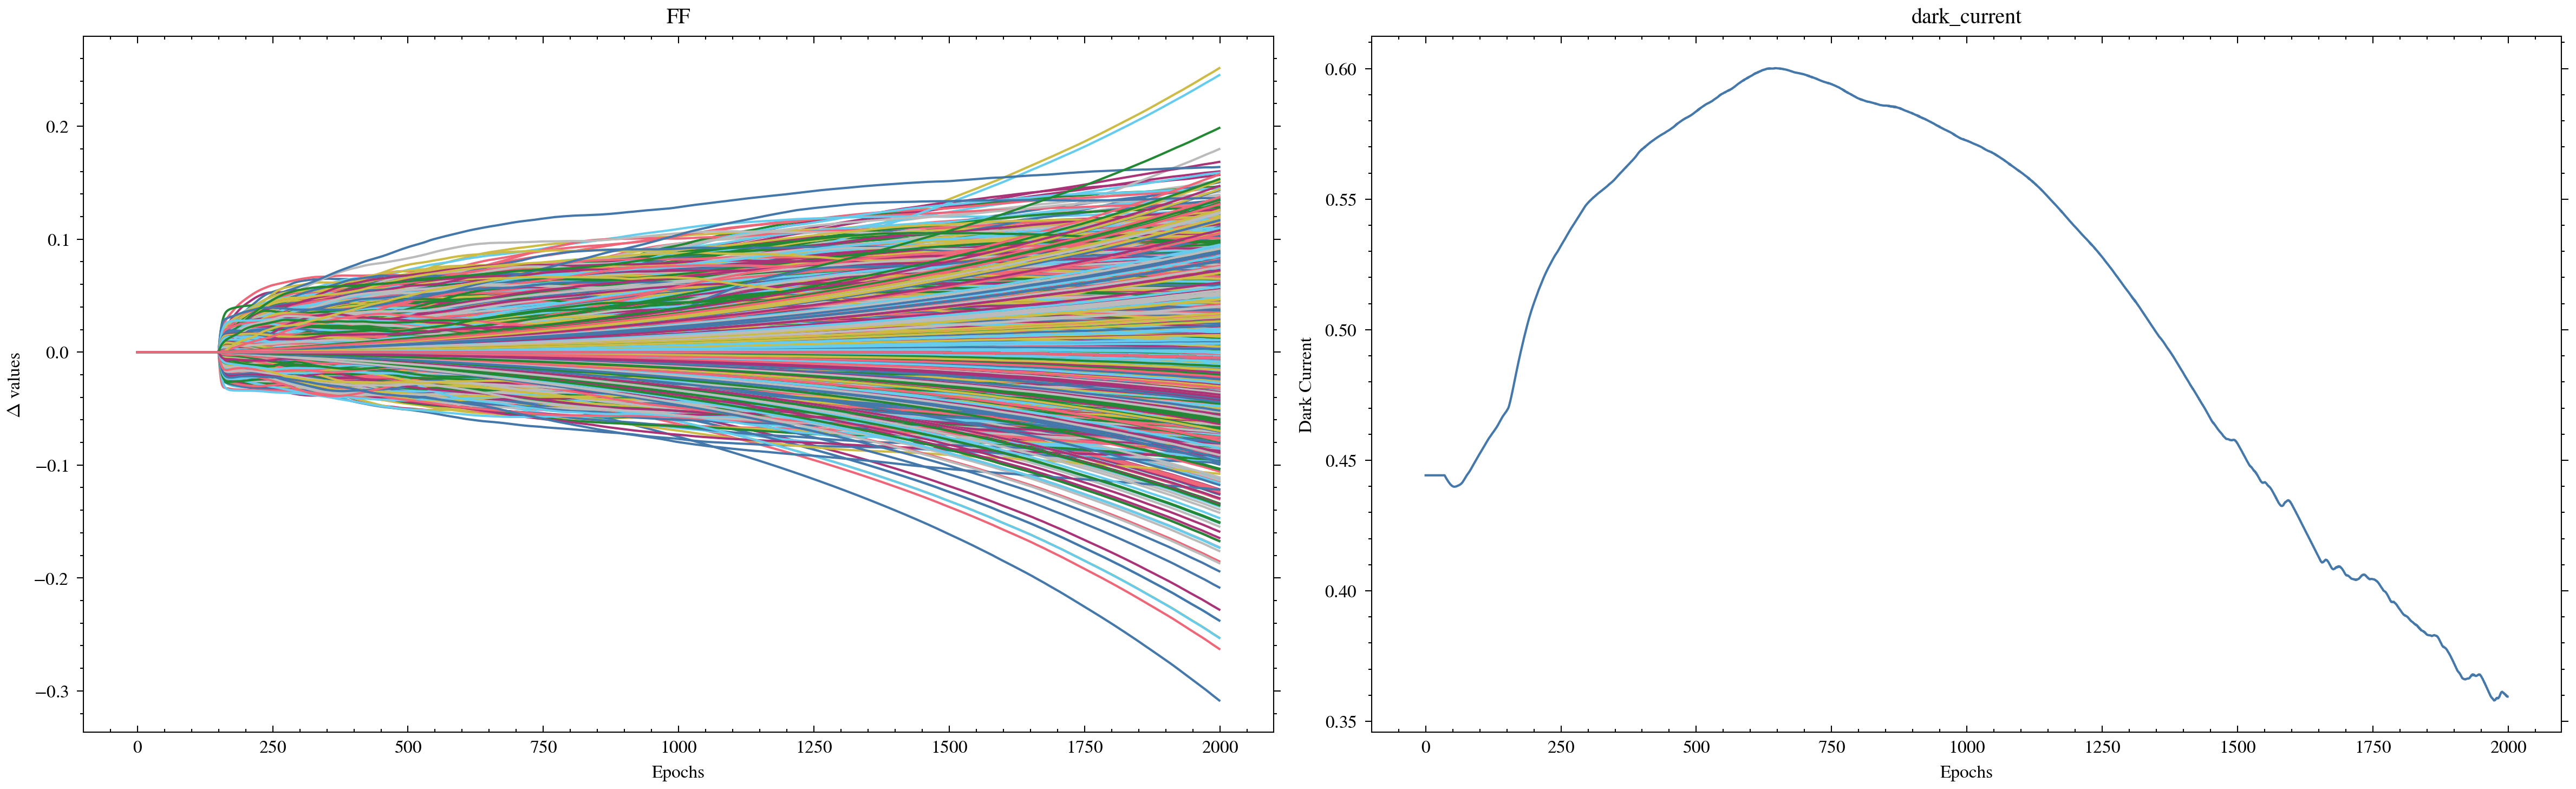

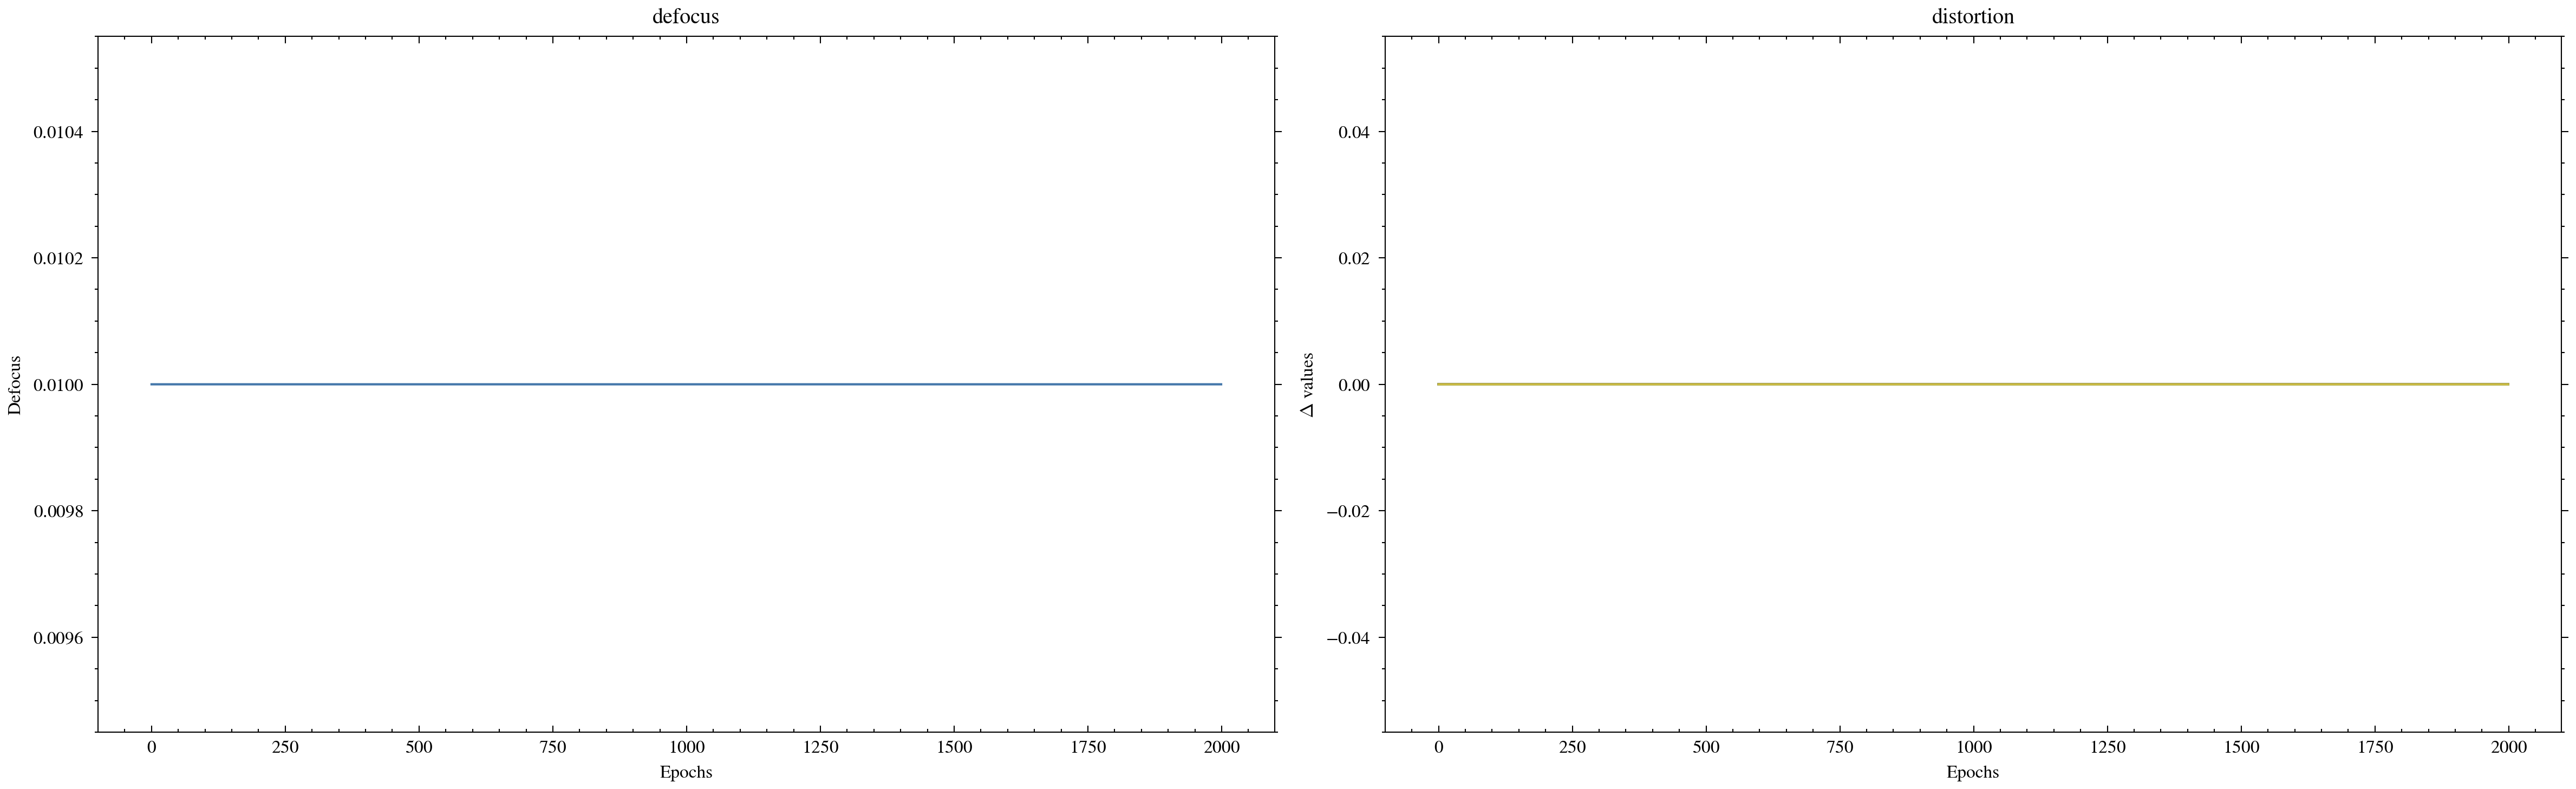

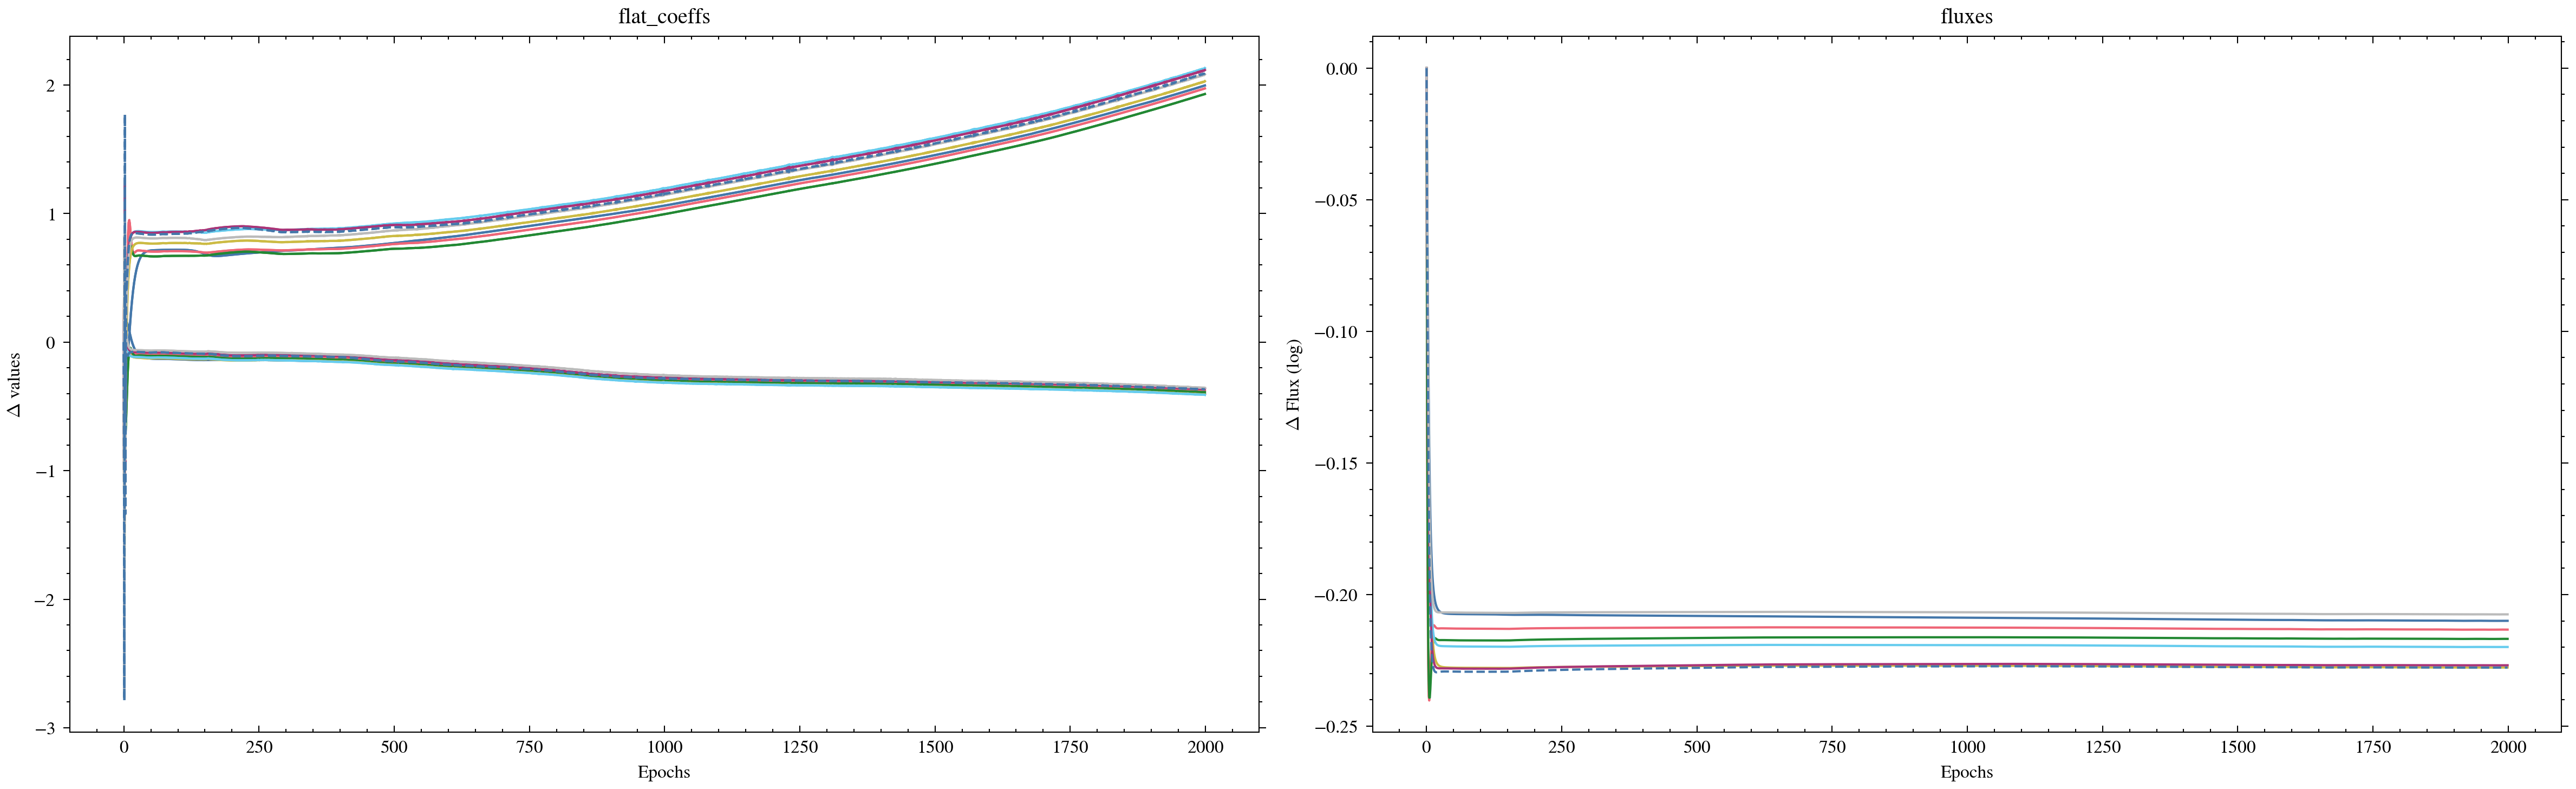

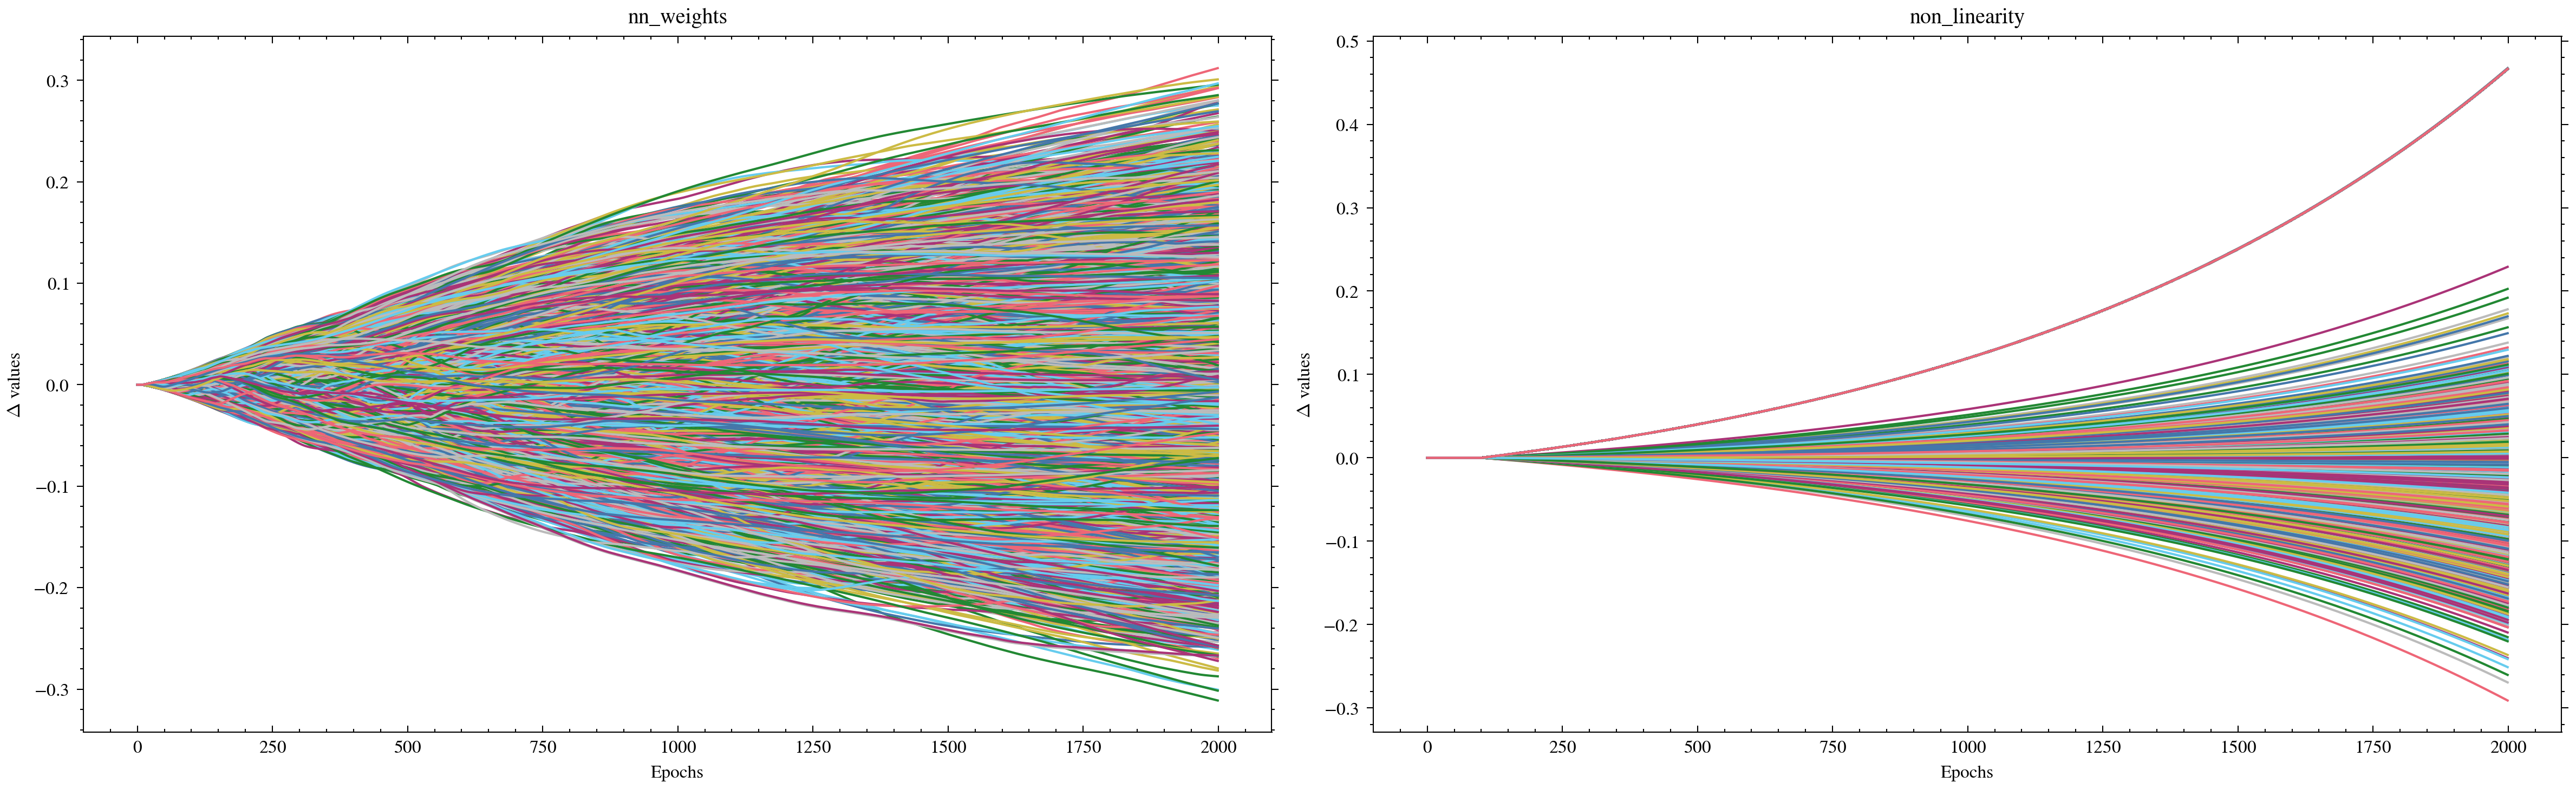

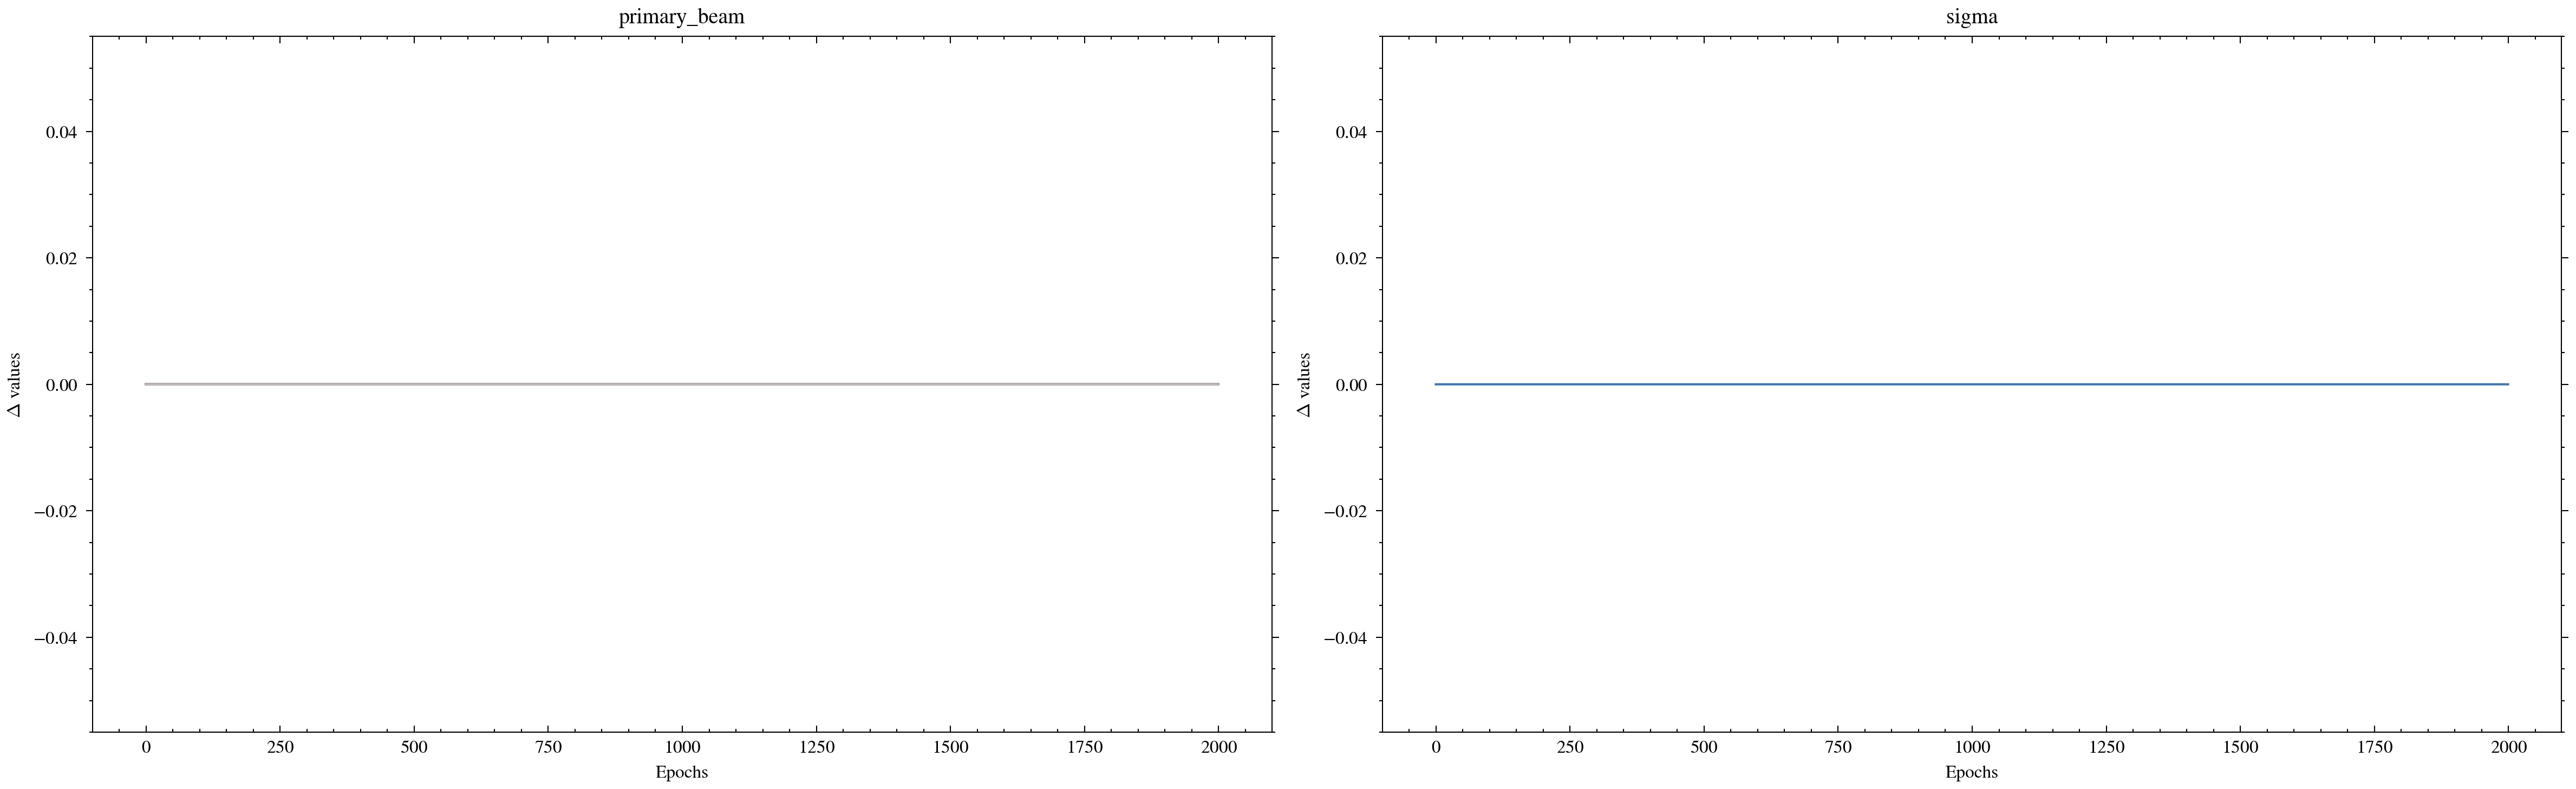

File flat_CLEAR_20
Star NIS_LAMP
Filter CLEAR
nints 33
ngroups 20



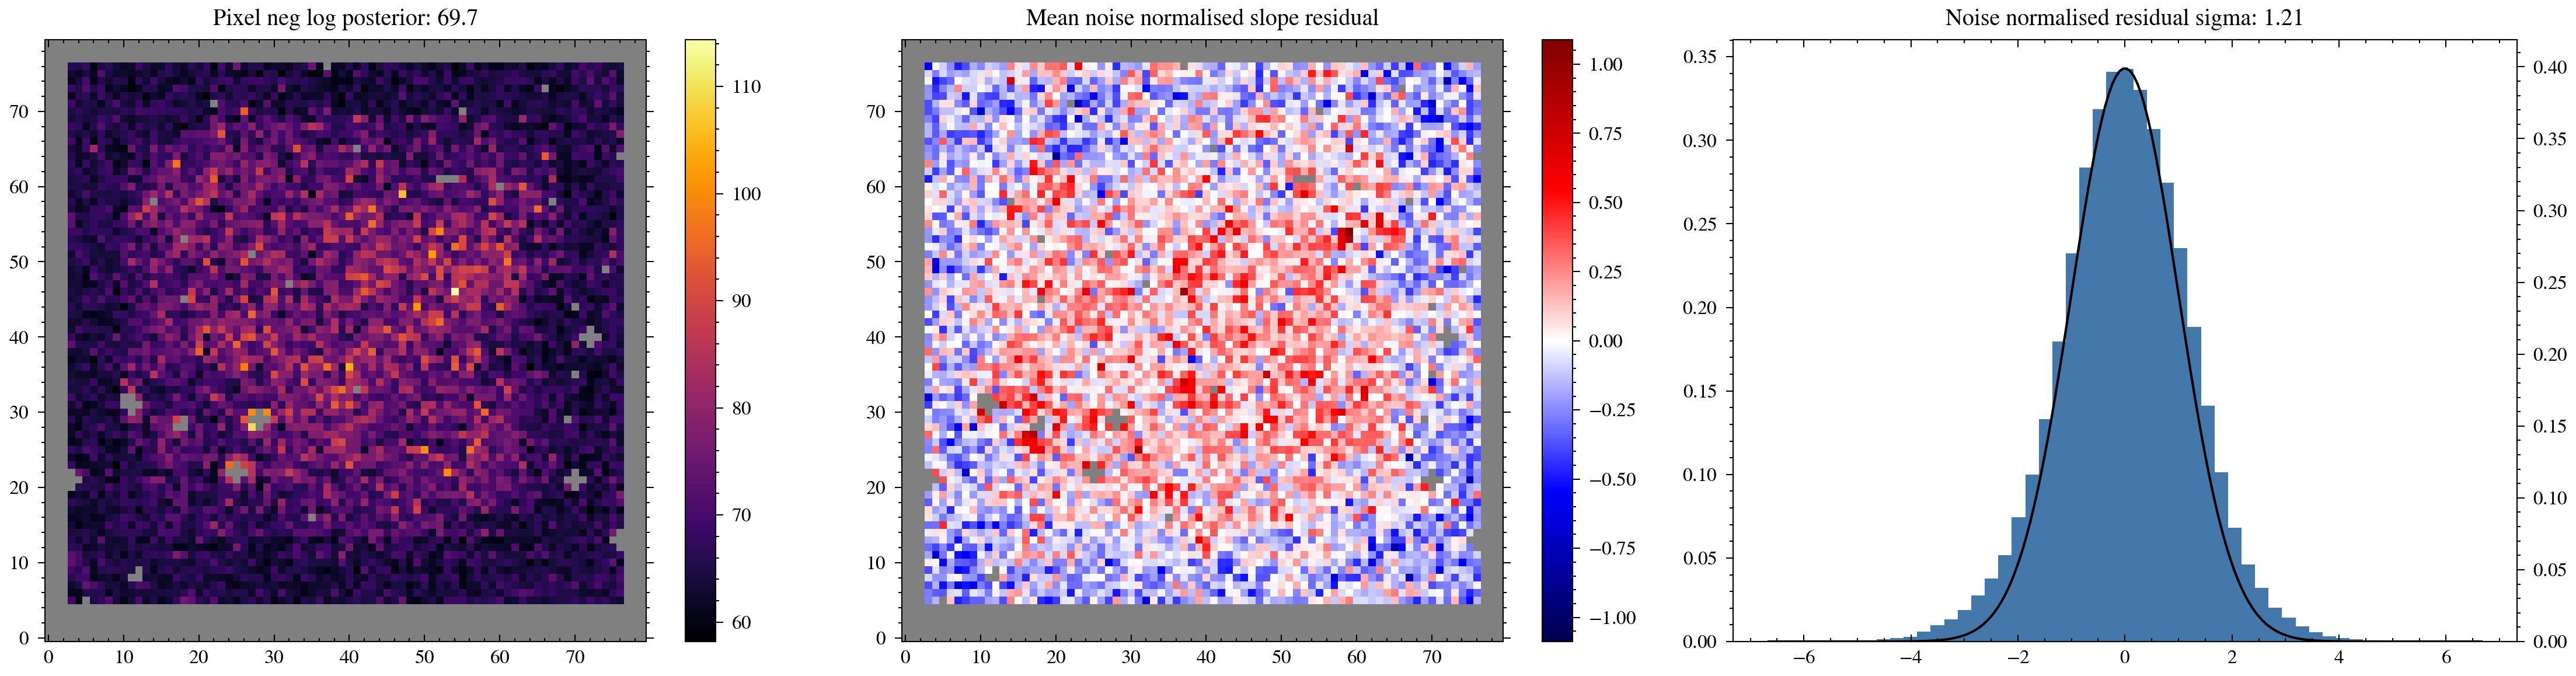

File flat_F380M_30
Star NIS_LAMP
Filter F380M
nints 10
ngroups 30



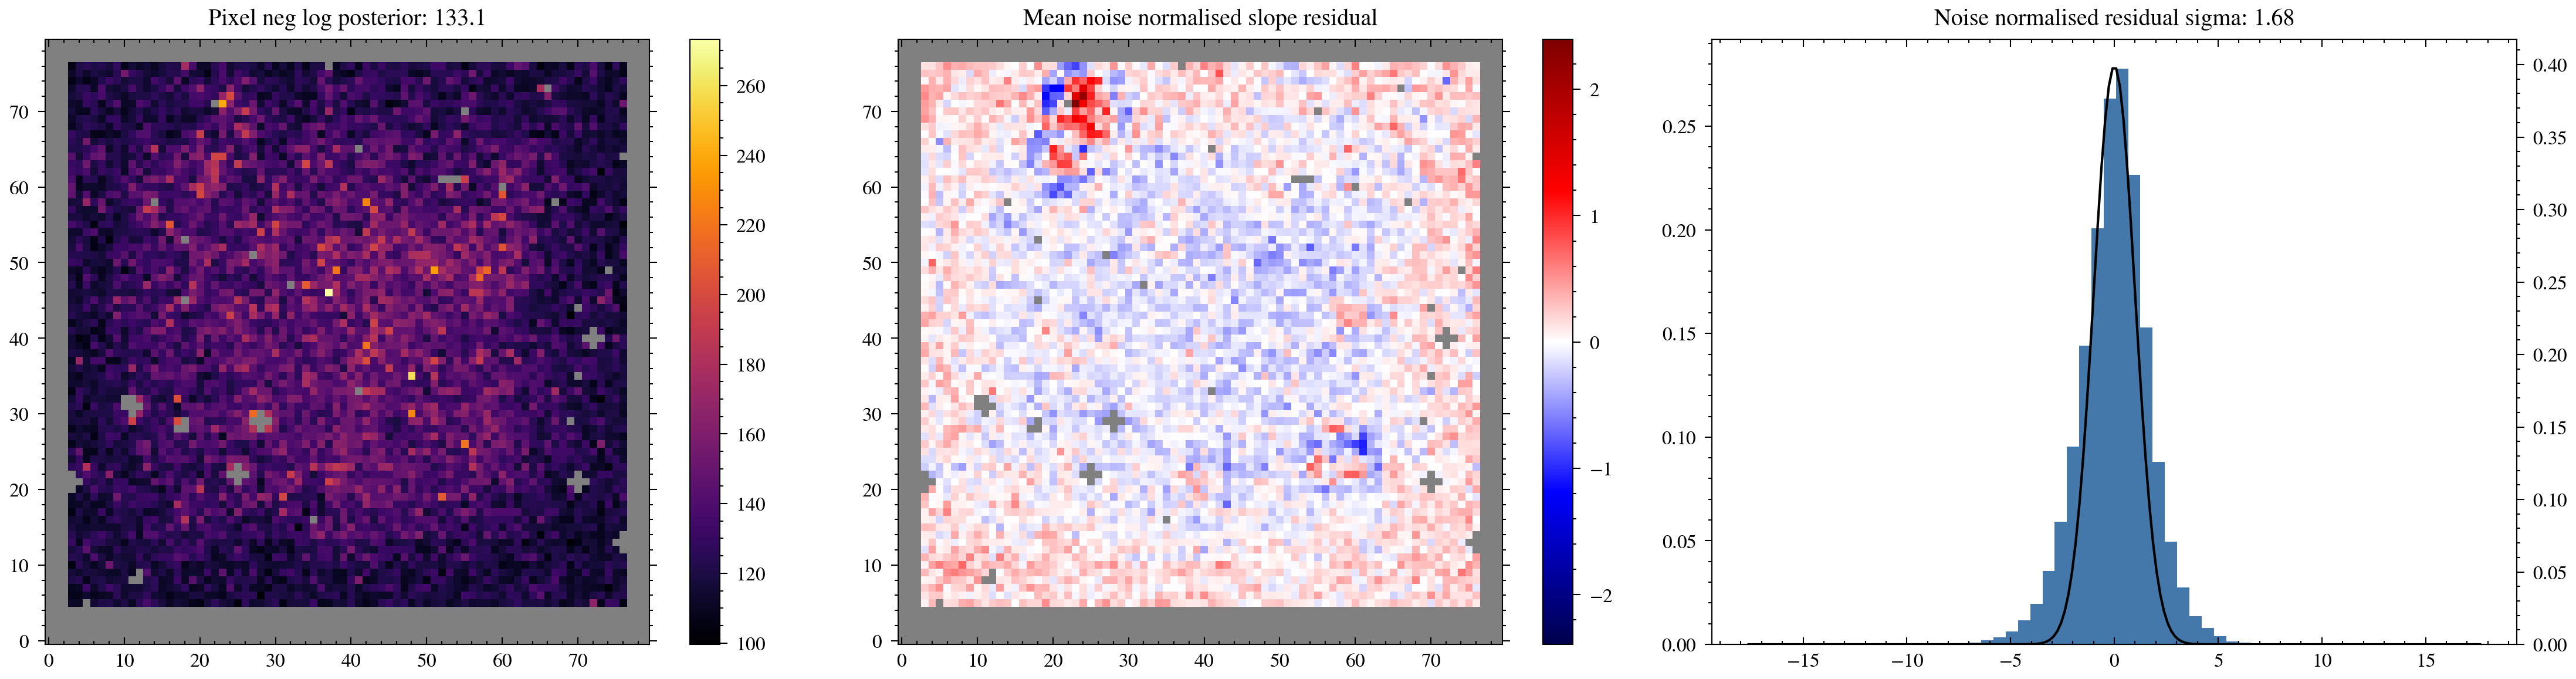

File flat_F444W_20
Star NIS_LAMP
Filter F444W
nints 10
ngroups 20



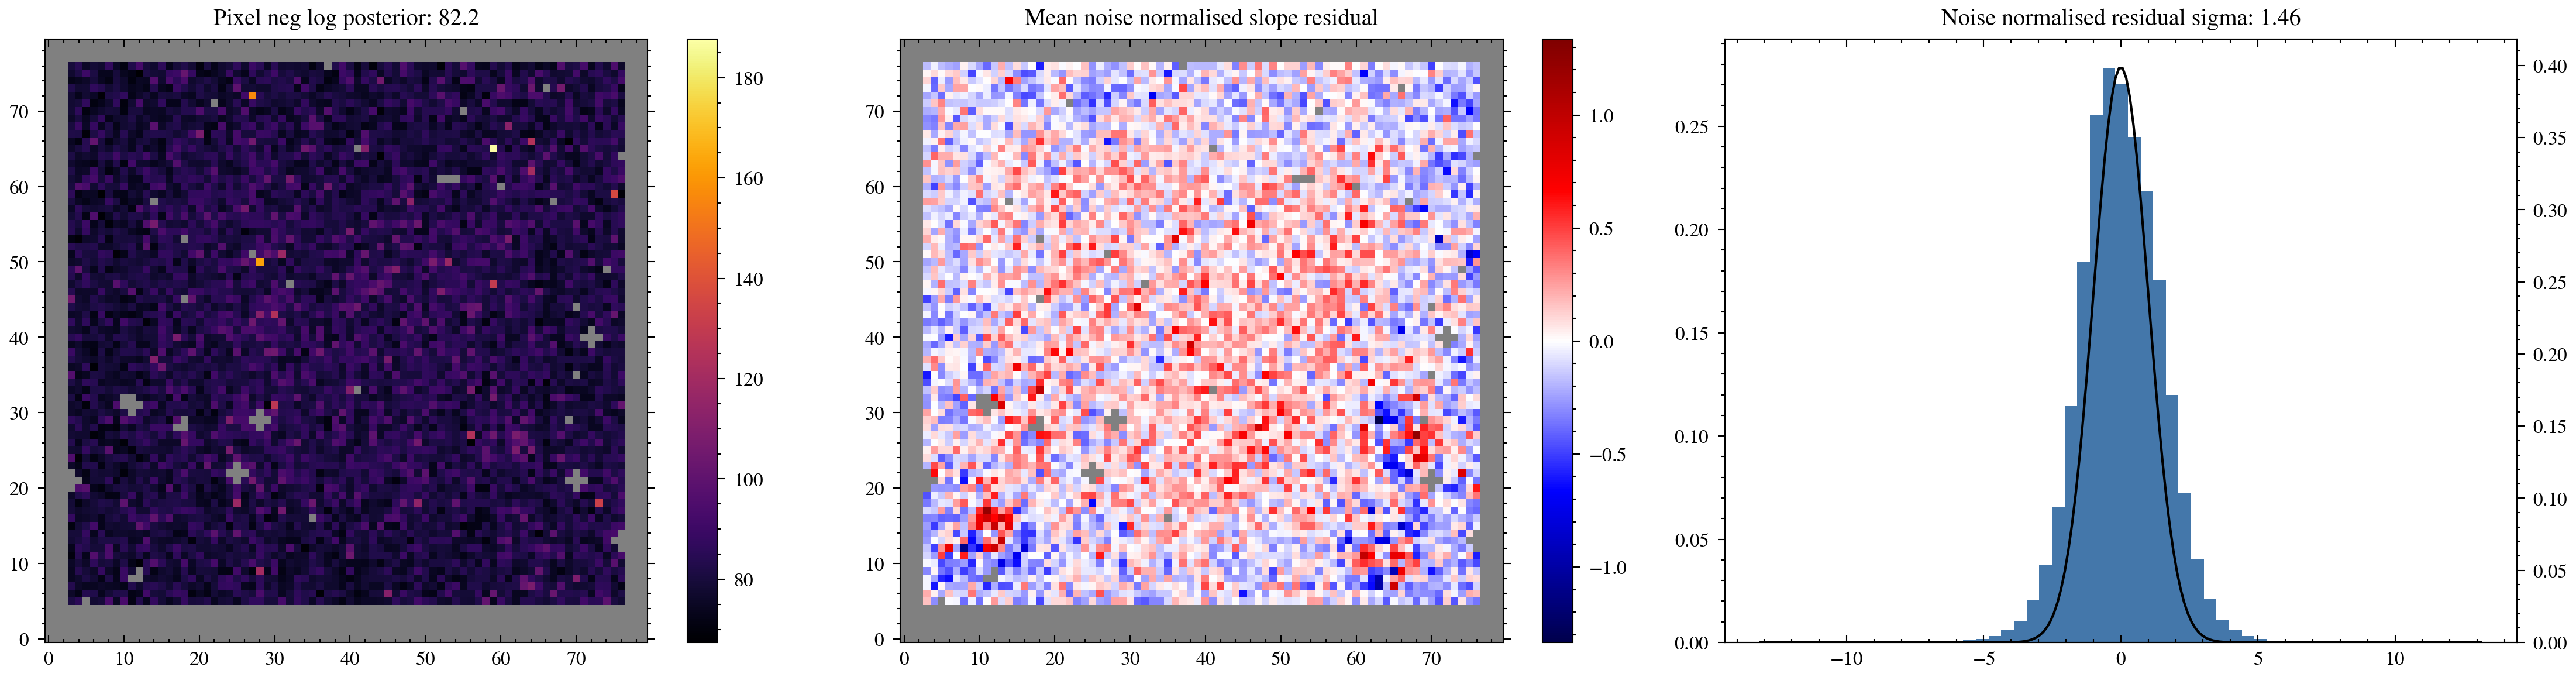

File flat_F480M_30
Star NIS_LAMP
Filter F480M
nints 10
ngroups 30



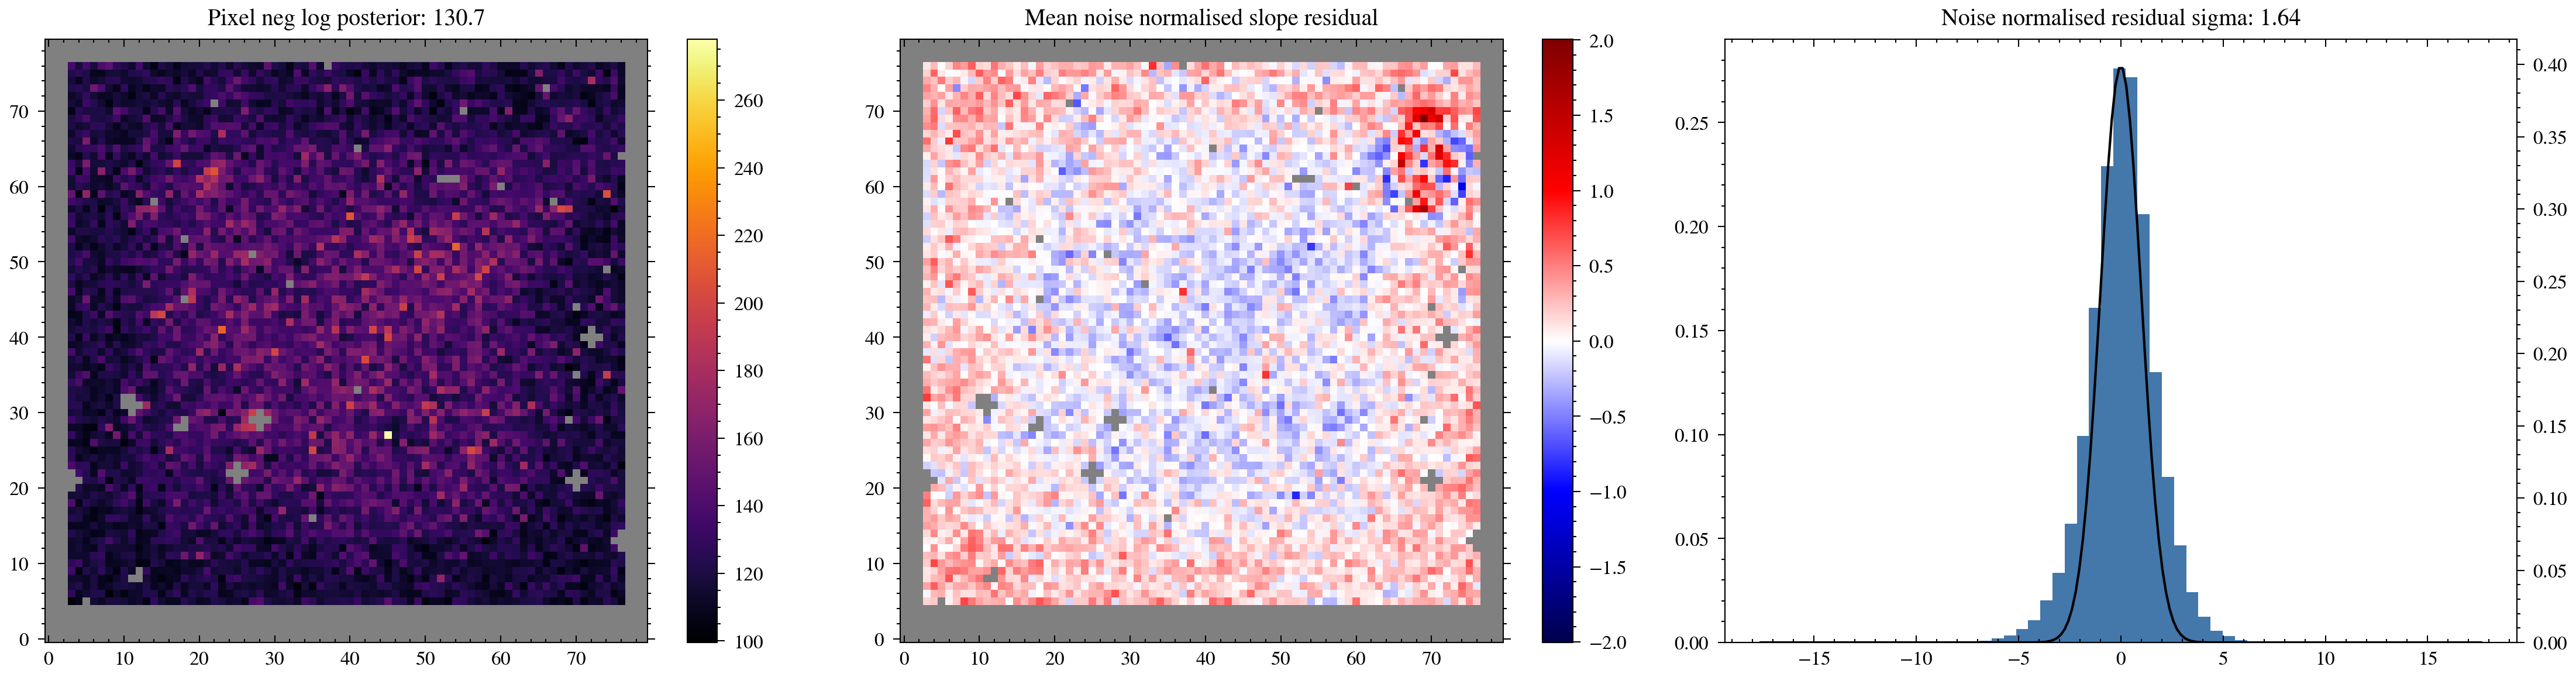

File flat_CLEAR_25
Star NIS_LAMP
Filter CLEAR
nints 11
ngroups 25



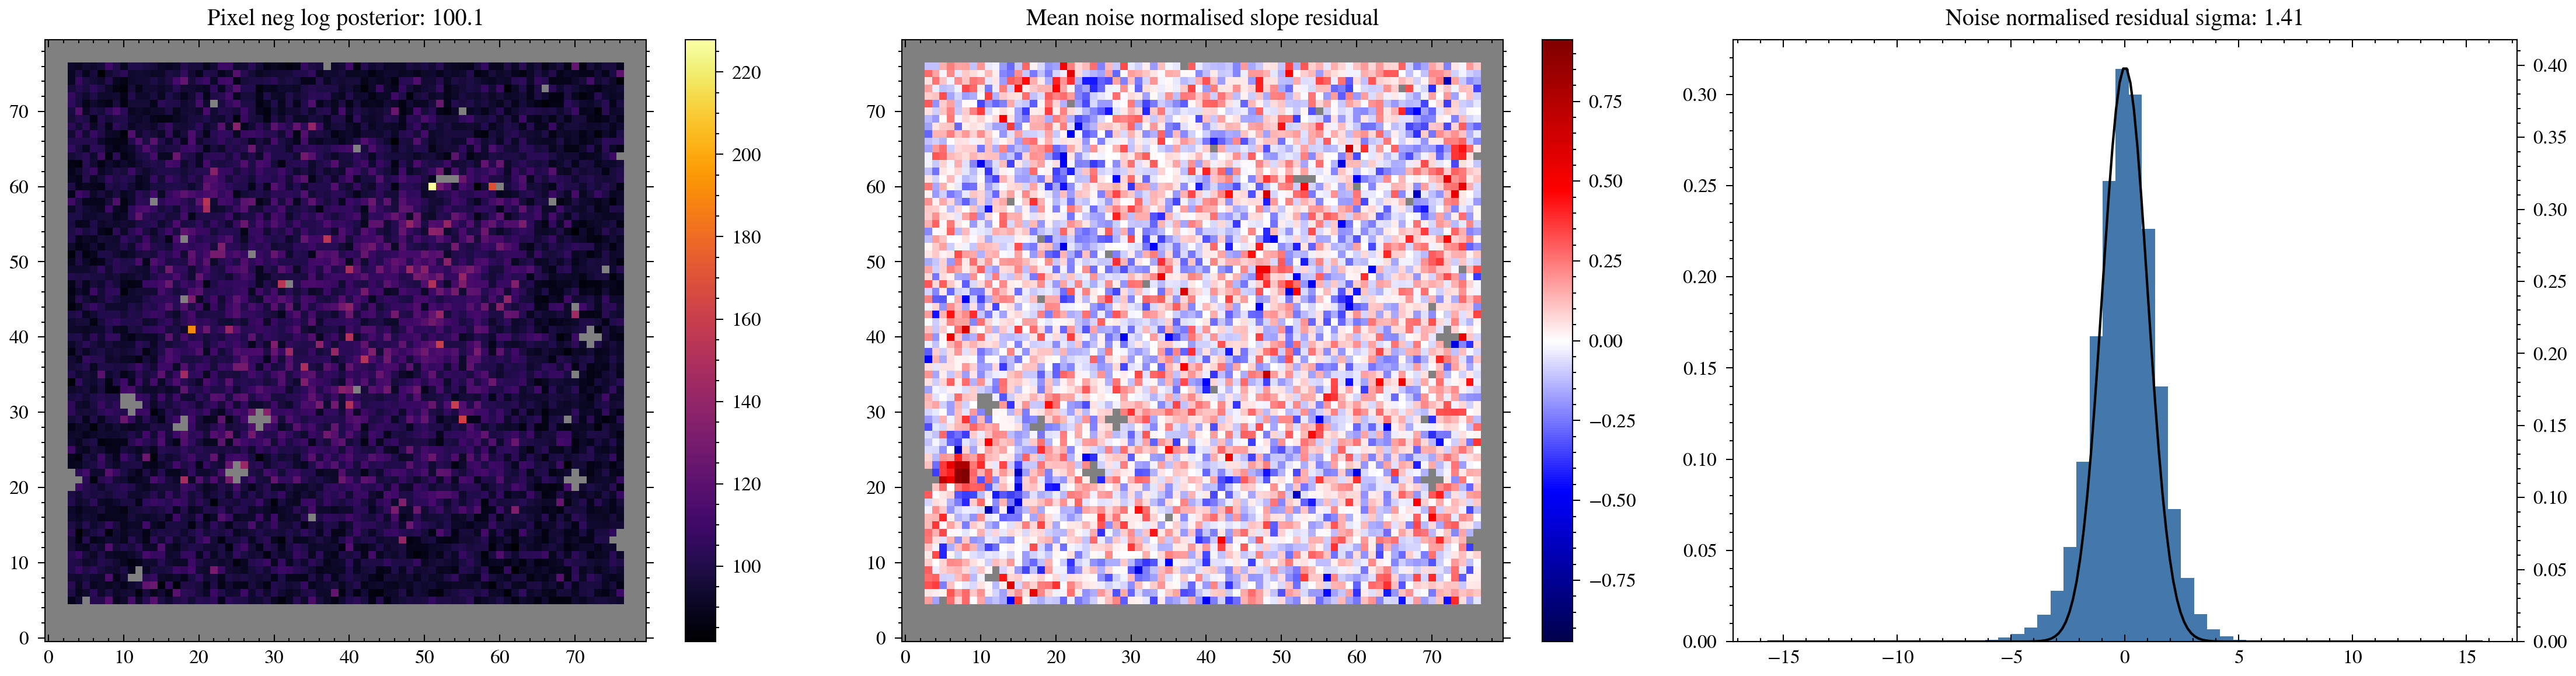

File flat_F277W_20
Star NIS_LAMP
Filter F277W
nints 10
ngroups 20



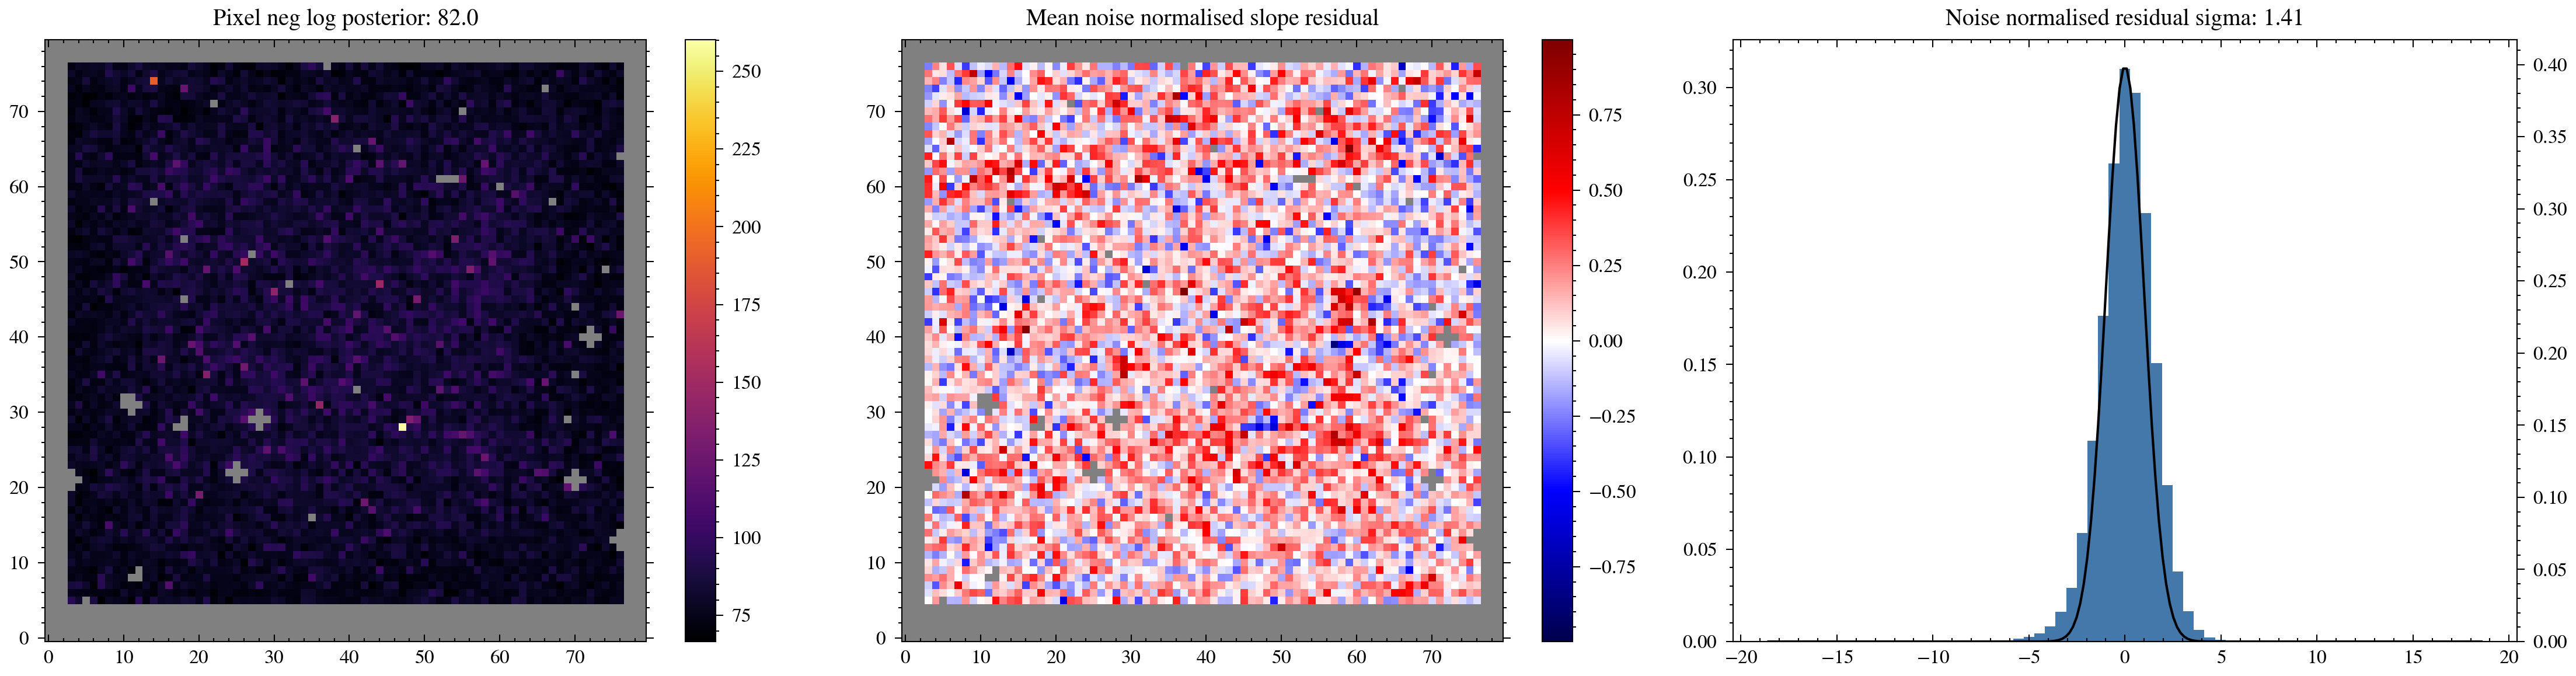

File flat_F356W_20
Star NIS_LAMP
Filter F356W
nints 10
ngroups 20



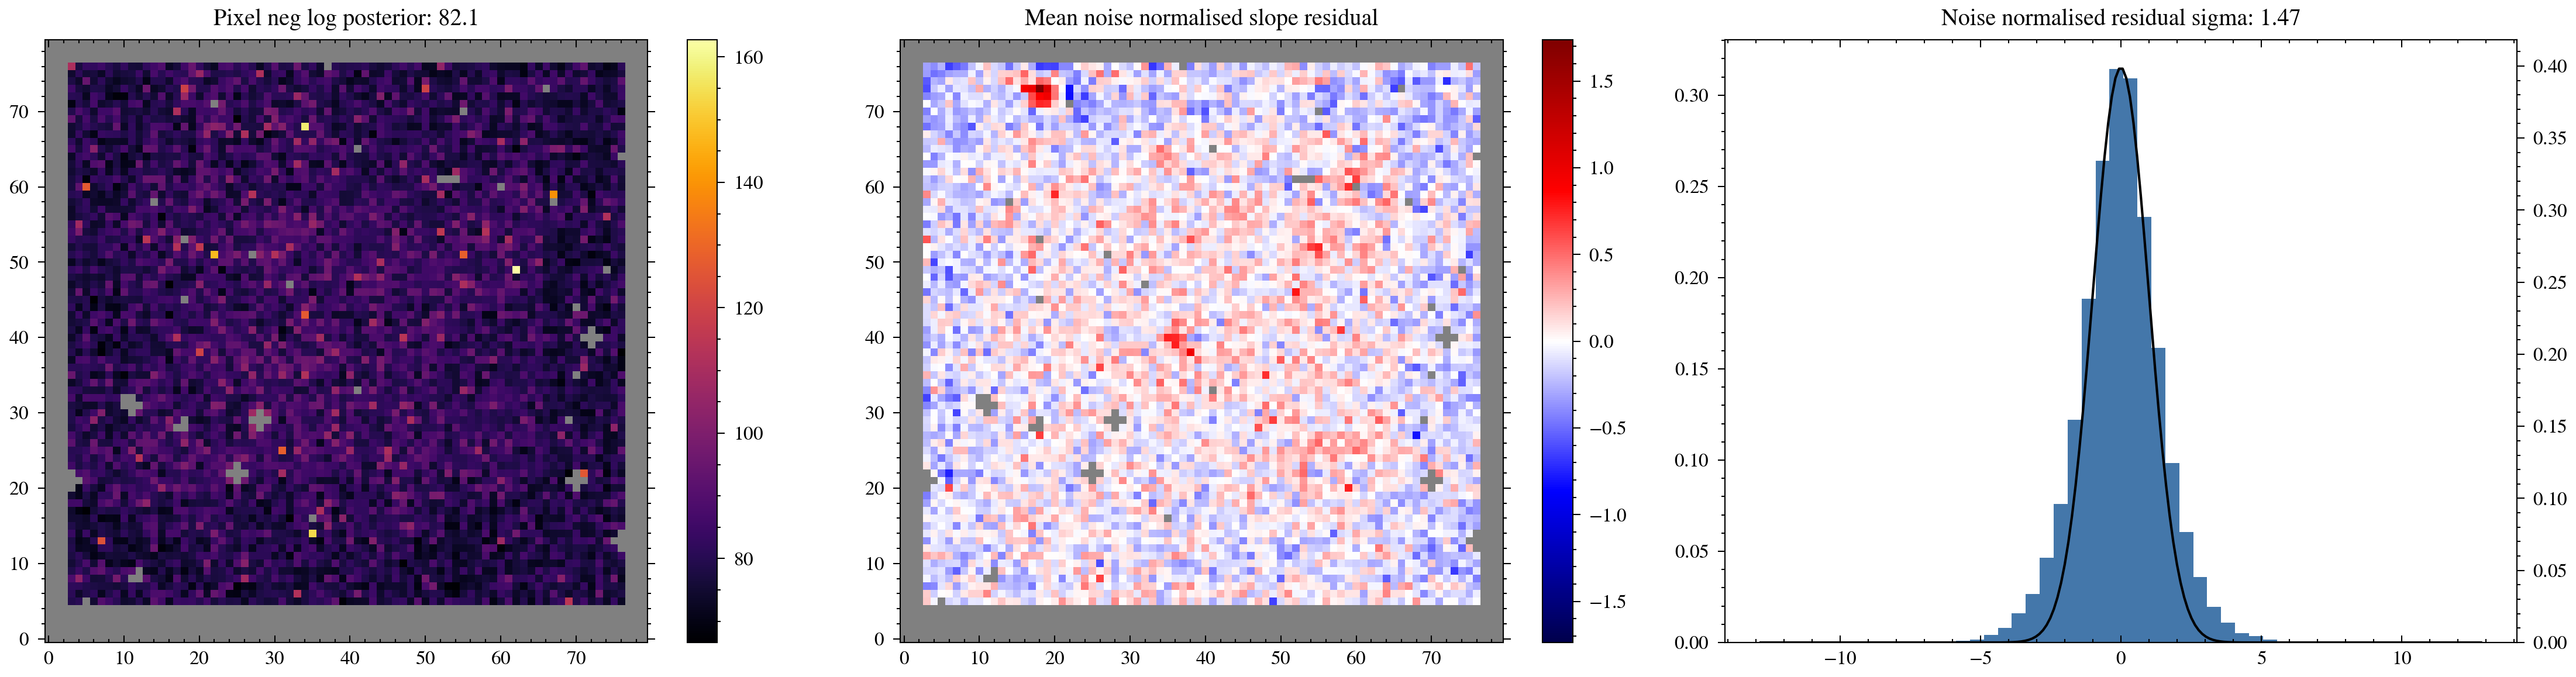

File flat_CLEAR_10
Star NIS_LAMP
Filter CLEAR
nints 11
ngroups 10



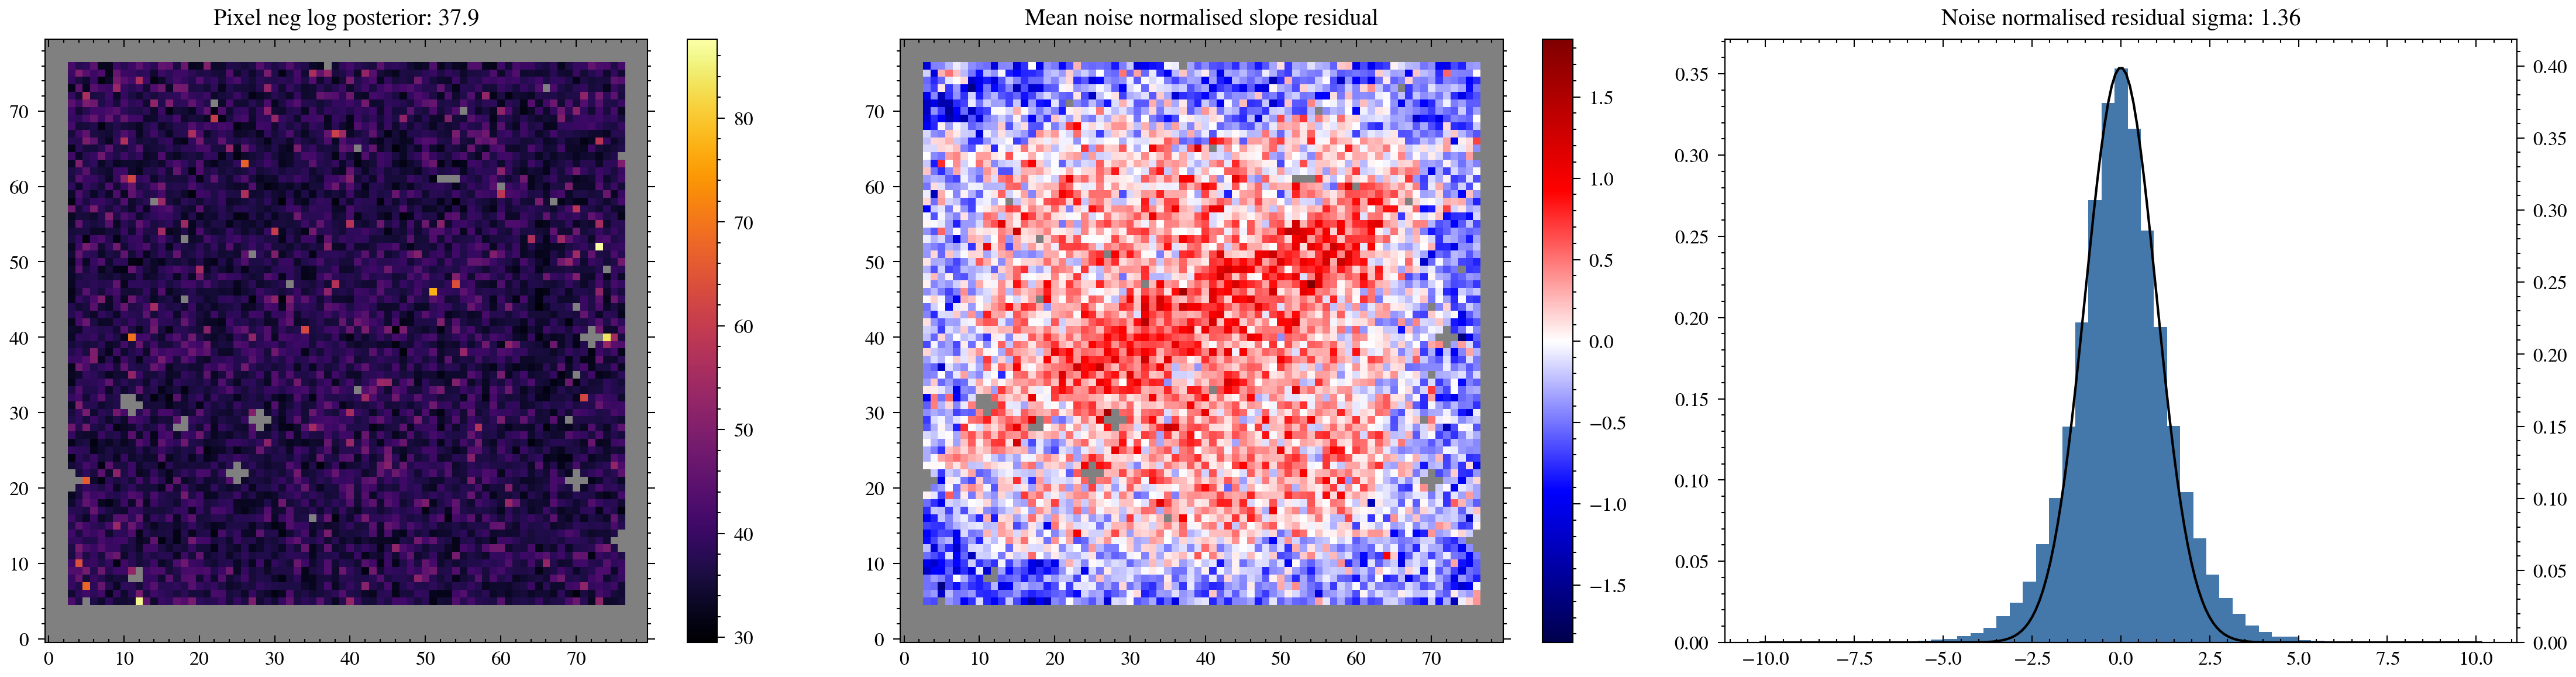

In [13]:
amigo.plotting.plot_losses(result.losses[0], start=int(0.75*epochs))
amigo.plotting.plot(result.history, save_path=save_path)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp, save_path=None)